In [10]:
import sys
!{sys.executable} -m pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pickle

# Load cleaned data 
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Dropping customerID — it's just an identifier, no predictive value
df.drop(columns=['customerID'], inplace=True)

print(df.shape)  

(7032, 20)


In [2]:
# Binary columns — simple Yes/No mapping
binary_cols = ['Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'gender']

for col in binary_cols:
    if df[col].dtype == object:
        df[col] = df[col].map(lambda x: 1 if x in ['Yes', 'Male'] else 0)

# Multi-category columns 
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=False)

print(f"Columns after encoding: {df.shape[1]}")  # ~40 columns
print(df.dtypes.value_counts())

Columns after encoding: 41
bool       31
str         5
int64       3
float64     2
Name: count, dtype: int64


In [3]:
# 1. Revenue per month of tenure (value efficiency)
# High charges + low tenure = expensive and new = high risk
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# 2. Total services subscribed
# Customers using more services are more "locked in"
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 
                'StreamingTV', 'StreamingMovies']
# Count from original before encoding — recreate from dummies
# Using a proxy: sum of all streaming/security dummies
streaming_sec_cols = [c for c in df.columns if any(
    s in c for s in ['OnlineSecurity', 'OnlineBackup', 
                     'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies']) 
    and 'No_' not in c and '_No ' not in c]
df['total_services'] = df[streaming_sec_cols].sum(axis=1)

# 3. Charge per service (value-for-money signal)
# High monthly charge but few services = likely to feel ripped off
df['charge_per_service'] = df['MonthlyCharges'] / (df['total_services'] + 1)

# 4. Is a high-value customer? (top 25% by monthly charges)
df['is_high_value'] = (df['MonthlyCharges'] > 
                        df['MonthlyCharges'].quantile(0.75)).astype(int)

# 5. Early tenure flag (highest risk window from EDA)
df['is_early_tenure'] = (df['tenure'] <= 6).astype(int)

# 6. Long-term customer flag
df['is_loyal'] = (df['tenure'] >= 36).astype(int)

# 7. Monthly to Total charges ratio
# Detects if customer recently increased spending (possible churn signal)
df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

print("New features added:")
new_features = ['charges_per_tenure', 'total_services', 'charge_per_service',
                'is_high_value', 'is_early_tenure', 'is_loyal', 
                'monthly_to_total_ratio']
print(df[new_features].describe().round(2))

New features added:
       charges_per_tenure  total_services  charge_per_service  is_high_value  \
count             7032.00         7032.00             7032.00        7032.00   
mean                 5.71            4.70               13.16           0.25   
std                  8.57            2.47                5.10           0.43   
min                  0.26            0.00                3.35           0.00   
25%                  1.25            6.00                9.82           0.00   
50%                  2.07            6.00               12.39           0.00   
75%                  5.88            6.00               15.67           0.25   
max                 51.22            6.00               26.90           1.00   

       is_early_tenure  is_loyal  monthly_to_total_ratio  
count          7032.00   7032.00                 7032.00  
mean              0.21      0.43                    0.15  
std               0.41      0.50                    0.27  
min               0.00 

In [4]:
# TotalCharges is redundant — already captured in tenure + MonthlyCharges
# and in our new ratio feature
df.drop(columns=['TotalCharges'], inplace=True)

print(f"Final feature count: {df.shape[1] - 1} features")  # minus target

Final feature count: 46 features


In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       
    random_state=42,     
    stratify=y           
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Train churn %  : {y_train.mean()*100:.1f}%")
print(f"Test churn %   : {y_test.mean()*100:.1f}%")


Training set   : 5,625 rows
Test set       : 1,407 rows
Train churn %  : 26.6%
Test churn %   : 26.6%


In [12]:
from imblearn.over_sampling import SMOTE

# Step 1: Drop customerID (it's useless for modeling)
X_train = X_train.drop(columns=['customerID'], errors='ignore')
X_test = X_test.drop(columns=['customerID'], errors='ignore')

# Step 2: One-Hot Encode all categorical columns
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Step 3: Align columns (in case test set ends up with different dummy columns)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Step 4: Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_encoded, y_train)

print("Before SMOTE:")
print(f"  Churned: {y_train.sum():,} | Not churned: {(y_train==0).sum():,}")
print()
print("After SMOTE:")
print(f"  Churned: {y_train_balanced.sum():,} | Not churned: {(y_train_balanced==0).sum():,}")

Before SMOTE:
  Churned: 1,495 | Not churned: 4,130

After SMOTE:
  Churned: 4,130 | Not churned: 4,130


In [14]:
from sklearn.preprocessing import StandardScaler
import pickle
import os

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_encoded) 

# Save the scaler and processed data 
os.makedirs('models', exist_ok=True)
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))

# Save processed datasets
os.makedirs('data', exist_ok=True)  
pd.DataFrame(X_train_scaled,
             columns=X_train_balanced.columns).to_csv('data/X_train.csv', index=False)  
pd.DataFrame(X_test_scaled,
             columns=X_test_encoded.columns).to_csv('data/X_test.csv', index=False)     
y_train_balanced.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

# Save feature names 
feature_names = list(X_train_balanced.columns)  
pickle.dump(feature_names, open('models/feature_names.pkl', 'wb'))

print("✓ All files saved.")

✓ All files saved.


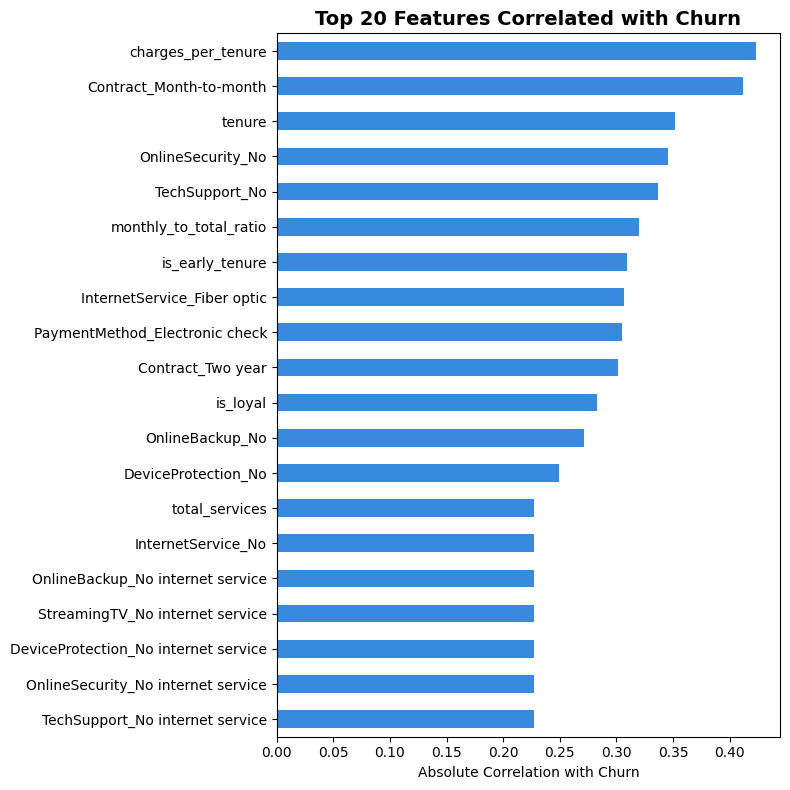

In [18]:
# Correlation of each feature with churn target
import matplotlib.pyplot as plt

feature_corr = X_train_encoded.corrwith(y_train).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
feature_corr.head(20).sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_title('Top 20 Features Correlated with Churn', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation with Churn')
plt.tight_layout()
plt.savefig('charts/06_feature_correlation.png', dpi=150)
plt.show()